# DAAAnalyzer_2.0_PlotABRs.ipynb
Created by: JFranco | Created On: 27 NOV 2024 | Last Env: QISHA | Last Run Date: 03 FEB 2025

This Python notebook reads in all analyzed and filtered ABR files to generate a .csv file that has ABRs for all files in the DAA run, 
generates waveform plots that allow the user to set thresholds while being blind to filename, generates waveform plots for every subject,
and generates group summary plots. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
from random import shuffle
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [2]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [3]:
# *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_010'
daaRun = '3'
daaType = '2 WKS Post Noise Exposure'
fnMD = prepID+'.Metadata.AnimalInfo.csv'

# Directories 
#   - Existing ones - 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'
dirSV = dirPrep+'Results/'
dirDFs = dirSV+"1_CompiledMeasurements/"
dirSjABRPlts = dirSV+"3_ABRPlotsBySubject/"
dirGpABRPlts = dirSV+"4_ABRPlotsByGroup/"
dirSjWOPlts = dirSV+"5_Wave1PlotsBySubject/"
dirGpWOPlts = dirSV+"6_Wave1PlotsByGroup/"

# Filenames
#    - Existing ones -
fnMD = prepID+'.Metadata.AnimalInfo.csv'
fnThs = prepID+'.ABRThresholds.DAA_'+daaRun+'.csv'

#    - Ones that will be made - 
fnABRVals = prepID+'.AllABRVals.DAA_'+daaRun+'.csv'
fnGBABRs = prepID+'.GroupABRStats.DAA_'+daaRun+'.csv'
fnPltPF = prepID+'.ABR.DAA_'+daaRun

In [4]:
#    *** LOAD MD SHEETS **
# Sample metadata sheet that include animal and condition info
dfMD = pd.read_csv(dirMD+fnMD)
dfMD.reset_index(inplace=True)
dfMD

,index,AnimalID,Sex,DOB,CMIID,InjectionDate,AgeAtInjection,Package,InjGroup,NE,NEDate,AgeAtNE,NELevel,NEBand,NEDuration,NEGroup
0,0,C058,M,11/26/24,CMI_010,1/5/25,6,AAV,Pink,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,C059,F,11/26/24,CMI_010,1/5/25,6,AAV,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,C060,M,11/26/24,CMI_010,1/5/25,6,NaN,NonInj,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,C062,M,11/26/24,CMI_010,1/5/25,6,AAV,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,C063,F,11/26/24,CMI_010,1/5/25,6,NaN,NonInj,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,C065,F,11/26/24,CMI_010,1/5/25,6,AAV,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,C066,F,11/26/24,CMI_010,1/5/25,6,NaN,NonInj,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,C067,F,11/19/24,CMI_010,1/5/25,7,NaN,NonInj,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#      *** GENERATE A LIST OF DAA FOLDERS THAT WILL BE ANALYZED **
# Get a list of all the folders that match the prep
allData = os.listdir(dirData)
dataList = []
for datum in allData:
    if ('.'+daaRun) in datum:
        dataList.append(datum)
dataList.sort()
dataList

['CMI_010.C058.3',
 'CMI_010.C059.3',
 'CMI_010.C060.3',
 'CMI_010.C062.3',
 'CMI_010.C063.3',
 'CMI_010.C065.3',
 'CMI_010.C066.3',
 'CMI_010.C067.3']

In [6]:
# *** GENERATE A DATAFRAME OF ALL ABR DATA FOR THIS RUN ***
dfAll = pd.DataFrame()
for daa in dataList:
    # Setup the path to the file
    abrFold = dirData+daa+'/'
    # Get a list of available ABR files
    allFiles = os.listdir(abrFold)
    anaFiles = []
    dfFAll = pd.DataFrame()
    for file in allFiles:
        # Only consider files that are analyzed 
        if ("analyzed.txt") in file:
            # Get information about the recording subject
            anID = daa[8:-2]
            # Get information about this animal from the MD sheet
            inMD = dfMD.index[dfMD['AnimalID']==anID].tolist()[0]
            inj = dfMD.loc[inMD]['InjGroup']
            sex = dfMD.loc[inMD]['Sex']
            # Get the base filename
            strFile = str(file)
            inPost = strFile.index("analyzed.txt")
            basename = strFile[0:(inPost-1)]
            # Open the analyzed file to get the ABR frequency for this file
            with open(abrFold+basename+"-analyzed.txt", "r") as f:
                anaABR = f.read()
                inPre = anaABR.index("(kHz):")
                inPost = anaABR.index("Threshold estimation:")
                freq = anaABR[(inPre+6):(inPost-4)]
            # Read in the analyzed ABR file 
            dfAA = pd.read_csv(abrFold+basename+"-analyzed.txt", sep="\t", skiprows=6)
            # Read in the filtered ABR file 
            dfFA = pd.read_csv(abrFold+basename+"-filtered.txt", delimiter='\t', header=0,index_col="Time (ms)")
            # Get the number of dB levels for the file
            for level in dfFA.columns:
                # Get the WI amplitudes for this level
                inLV = dfAA.index[dfAA[dfAA.columns[0]]==float(level[0:-3])].tolist()[0]
                waveOne = dfAA.loc[inLV]['P1 Amplitude']
                data = {'AnimalID':anID,"CMIID":prepID,"Sex":sex,"InjGroup":inj,
                        "AnimalFile":anID+"."+basename, "File":basename,"DAA_Run":daaRun,
                       "Freq_kHz":float(freq),"Level":float(level[0:-5]), "Time_ms":dfFA.index,"Amp_uV":dfFA[level].values,"P1_Amplitude_uV":waveOne}
                df = pd.DataFrame(data)
                df['AnimalID'] = anID
                df['CMIID'] = prepID
                df['DAA_Run'] = daaRun
                dfAll = pd.concat([dfAll,df])

# Save the main df that has ABR data for all files in this run 
dfAll['Level_Fl'] = dfAll['Level'].astype(float)
dfAll.reset_index(inplace=True)
dfAll.to_csv(dirDFs+fnABRVals) 

In [7]:
# *** IDENTIFY THRESHOLDS FOR EACH ABR FILE ***
#  DO NOT NEED TO DO THIS MORE THAN ONCE -- SEE CELL BELOW FOR CODE TO OPEN EXISTING FILE 
#       THAT ALREADY HAS BLINDED THRESHOLD DATA
#  Open the ABR threshold file made in the initialization notebook
dfThs = pd.read_csv(dirDFs+fnThs, index_col=0)
# Get list of all files to eval & randomize the order
allFiles = dfAll["AnimalFile"].unique()
random.shuffle(allFiles)
for file in allFiles:
    # Get metadata for this file
    inFile = dfAll.index[dfAll['AnimalFile']==file].tolist()[0]
    anID = dfAll.loc[inFile]['AnimalID']
    # Setup graph to show user to get threshold for this file
    g = sns.FacetGrid(dfAll[dfAll['AnimalFile']==file], row="Level", aspect=4, height=1, 
                  row_order=np.sort(dfAll["Level"].unique())[::-1],hue="Level")
    g.map(sns.lineplot, "Time_ms", "Amp_uV")
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .5, label, fontweight="bold", color=color,
                ha="right", va="center", transform=ax.transAxes)
    g.map(label, "Level")
    # Adjust plot aesthetics
    g.set(xlim=(0, 9), ylim=(-2.5, 2.5))
    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.1)
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set(xlabel="Time (msec)")
    g.despine(bottom=True, left=True)
    plt.show()
    # Get threshold from user
    th = input("What is the threshold for this file?\n"+
                "Be sure to enter it as shown on the plot: ")
    clear_output(wait=True)
    # Get threshold & 80 dB wave I amplitudes for this file
    #    Find the index for the th
    dfSS = dfAll[dfAll['AnimalFile']==file]
    inTh = dfSS.index[dfSS['Level']==float(th)].tolist()[0]
    wOneTh = dfSS.loc[inTh]['P1_Amplitude_uV']
    inEdB = dfSS.index[dfSS['Level']==80.0].tolist()[0]
    wOneEdB = dfSS.loc[inEdB]['P1_Amplitude_uV']
    # Get the index for this file/animalID combination from the thresholds df
    inThDF = dfThs.index[(dfThs['AnimalID']==anID)&(dfThs['File']==file[5:])].tolist()[0]
    # Set the values in the threshold df for this entry
    dfThs.loc[inThDF, 'Th_dB_Blinded'] = float(th)
    dfThs.loc[inThDF, 'W1uV_Th'] = wOneTh
    dfThs.loc[inThDF, 'W1uV_80dB'] = wOneEdB

# Close the final plot & verify to user that all thresholds have been set
plt.close()
print('Thresholds have been identified for all runs')
# Save the threshold df 
dfThs.reset_index(inplace=True)
dfThs.to_csv(dirDFs+fnThs) 

Thresholds have been identified for all runs


In [9]:
### OR ###
### RECALL EXISTING THRESHOLD FILE IF IT EXISTS ###
# Sample metadata sheet that include animal and condition info
dfThs = pd.read_csv(dirDFs+fnThs)
dfThs.drop(['Unnamed: 0','index'], axis=1, inplace=True)

In [8]:
dfThs['Th_dB'] = dfThs['Th_dB_Blinded'].astype(float)

In [9]:
# *** CALCULATE GROUP STATISTICS ***
# Calculate ABR threshold stats per frequency
#    Drop columns that are not needed for groupby stats
df = dfThs.drop(['AnimalID','CMIID','DAA_Run','Sex','File'], axis=1)
grpTh = df.groupby(['InjGroup', 'Freq_kHz'])
grpThStats = grpTh.describe()
grpThStats.to_csv(dirDFs+fnGBABRs, index=True)

In [10]:
# *** MAKE SUBJECT SUMMARY PLOTS ***
# Get the maximum waveI  amplitude for all subjects to use the same axis for all subjects
#maxY = round(dfAll['P1_Amplitude_uV'].max())
maxY = 2
# Iterate through all of the subjects
for daa in dataList:
    # Get information about the recording subject
    anID = daa[8:-2]
    daaRun = daa[-1:]
    # *** Create & save the ABR Waveform plots for all available ABR files for this animal ***
    g = sns.FacetGrid(dfAll[dfAll["AnimalID"]==anID], col="Freq_kHz",row="Level", aspect=4, height=1, 
                      col_order=np.sort(dfAll["Freq_kHz"].unique()), row_order=np.sort(dfAll["Level"].unique())[::-1],hue="Level", margin_titles=True)
    g.map(sns.lineplot, "Time_ms", "Amp_uV")
    g.tight_layout()
    g.refline(y=0, linewidth=.5, linestyle="--", color=None, clip_on=False)
    g.refline(x=2, linewidth=.5, linestyle="--", color=None, clip_on=False)
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .5, label+" dB", fontweight="bold", color=color,
                ha="right", va="center", transform=ax.transAxes)
    g.map(label, "Level")
    # Adjust plot aesthetics
    g.set(xlim=(0, 9), ylim=(-2.5, 2.5))
    g.figure.subplots_adjust(hspace=-.2)
    g.figure.suptitle(prepID+" | "+anID+" | "+daaType, fontsize=12)
    g.fig.subplots_adjust(top=.95)
    g.set_titles(col_template="{col_name}", row_template=" ")
    g.set(yticks=[], ylabel="")
    g.set(xlabel="Time (msec)")
    g.despine(bottom=True, left=True)
    # Save the figure
    plt.savefig(dirSjABRPlts+prepID+'.ABRWaveforms.'+anID+'.'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')
    plt.close()

    # *** Create & save the Wave 1 amplitudes for all available ABR files for this animal ***
    ax = sns.lineplot(dfAll[dfAll["AnimalID"]==anID], x="Level_Fl", y="P1_Amplitude_uV",hue="Freq_kHz")
    ax.set_title(prepID+" "+anID+" | "+daaType)
    ax.set(xlabel="Tone Level (dB SPL)")
    ax.set(ylabel="Wave One Amplitude (uV)")
    ax.set_ylim((0, maxY))
    # Add reference lines for each frequency
    freqs = np.sort(dfAll[dfAll["AnimalID"]==anID]['Freq_kHz'].unique())
    # Indexer for positioning text next to vertical line
    i = 0;
    for freq in freqs:
        # Get the threshold at this frequency
        inTh = dfThs.index[(dfThs['AnimalID']==anID)&(dfThs['Freq_kHz']==freq)].tolist()[0]
        th = dfThs.loc[inTh]['Th_dB']
        plt.axvline(x=float(th), linewidth=.5, linestyle="--", color=None, clip_on=False)
        plt.text(float(th),(maxY-.5)-(i*.3),str(freq)+"kHz",rotation=90, fontsize=8)
        i=i+1
    plt.savefig(dirSjWOPlts+prepID+'.WaveOneAmps.'+anID+'.'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')
    plt.close()

In [11]:
# Get list of available frequencies to analyze
freqsToAna = dfAll['Freq_kHz'].unique()

In [12]:
# *** MAKE GROUP SUMMARY ABR PLOTS ***
# Iterate through all frequencies and make one facet grid plot per freq
for freq in freqsToAna:
    dfSS = dfAll[dfAll["Freq_kHz"]==freq]
    g = sns.FacetGrid(dfSS, col="InjGroup",row="Level", aspect=4, height=1, 
                      col_order=dfSS["InjGroup"].unique(), row_order=np.sort(dfSS["Level"].unique())[::-1],hue="Level")
    g.map(sns.lineplot, "Time_ms", "Amp_uV")
    g.tight_layout()
    g.refline(y=0, linewidth=.5, linestyle="--", color=None, clip_on=False)
    g.refline(x=2, linewidth=.5, linestyle="--", color=None, clip_on=False)
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .5, label, fontweight="bold", color=color,
                ha="right", va="center", transform=ax.transAxes)
    g.map(label, "Level")
    # Adjust plot aesthetics
    g.set(xlim=(0, 9), ylim=(-2.5, 2.5))
    g.figure.subplots_adjust(hspace=-.2)
    g.figure.suptitle(prepID+" | "+daaType+" | "+str(freq)+" kHz", fontsize=12)
    g.fig.subplots_adjust(top=.95)
    g.set_titles(col_template="{col_name}", row_template=" ")
    g.set(yticks=[], ylabel="")
    g.set(xlabel="Time (msec)")
    g.despine(bottom=True, left=True)
    # Save the figure
    plt.savefig(dirGpABRPlts+prepID+'.ABRWaveforms.'+str(freq)+'kHz.DAA_'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')
    plt.close()

In [13]:
# **** MAKE GROUP SUMMARY WAVE I PLOTS ****
# Get list of injGroups
injGrps = dfAll['InjGroup'].unique()
maxY = 2
# Iterate through all frequencies and make one facet grid plot per freq
for freq in freqsToAna:
    dfSS = dfAll[dfAll["Freq_kHz"]==freq]
    ax = sns.lineplot(dfSS, x="Level_Fl", y="P1_Amplitude_uV",hue="InjGroup", palette=colors)
    ax.set_title(prepID+" | "+daaType+" | "+str(freq)+" kHz")
    ax.set(xlabel="Tone Level (dB SPL)")
    ax.set(ylabel="Wave One Amplitude (uV)")
    ax.set_ylim((0, maxY))
    # Iterate through the groups and add their mean threshold    
    #  Indexer for positioning text next to vertical line
    i = 0;
    for grp in injGrps:
        # Get the threshold at this frequency
        grpMnTh = grpThStats.loc[(grp,freq)]['Th_dB']['mean']
        grpMnTh = str(grpMnTh)[0:-2]
        plt.axvline(x=float(grpMnTh), linewidth=.5, linestyle="--", color=None, clip_on=False)
        plt.text(float(grpMnTh),(maxY-.5)-(i*.3),grp,rotation=90, fontsize=8)
        i=i+1

    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
    leg = ax.get_legend()
    noHandles = len(leg.legend_handles)
    i=0
    for i in range(0, noHandles):
        leg.legend_handles[i].set_color(legColors[i])
    plt.savefig(dirGpWOPlts+prepID+'.WaveOneAmps.'+str(freq)+'kHz.DAA_'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')
    plt.close()

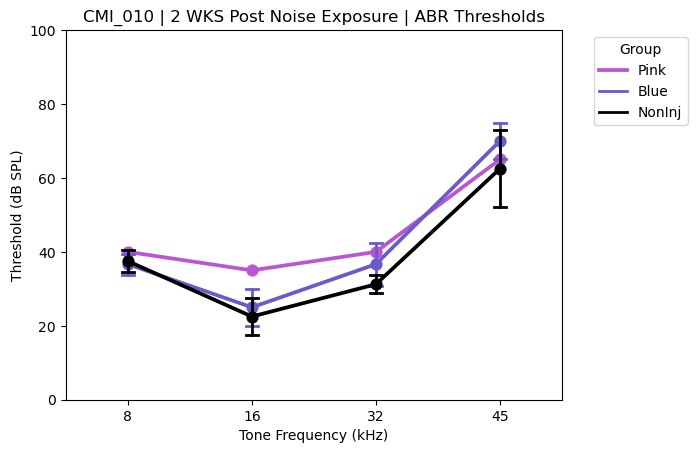

In [14]:
dfThs['Threshold'] = dfThs['Th_dB_Blinded'].astype(float)
ax = sns.pointplot(dfThs, x="Freq_kHz", y="Threshold",hue="InjGroup", palette=colors, errwidth=2, capsize=0.1, ci='sd')
ax.set_title(prepID+" | "+daaType+" | ABR Thresholds")
ax.set(xlabel="Tone Frequency (kHz)")
ax.set(ylabel="Threshold (dB SPL)")
ax.set_ylim((0, 100))

plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=conditions)
leg = ax.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
plt.savefig(dirGpABRPlts+prepID+'.ABRThresholds.DAA_'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')